# NB02 Homework Solutions

Answers to the "Homework / Practice Ideas" section of
`NB02_Python_and_Colab_Essentials_First_Naval_Dataset.ipynb`:

1. Finish the list-comprehension exercise from Part 1 (names of ships longer than 150 m).
2. Write your own `fib3.py` that returns the first `N` even Fibonacci numbers only.
3. Load `Naval_Dataset2.csv` or `Naval_Dataset3.csv` (same column structure) and repeat the full EDA workflow.
4. Try `%timeit` on your own function and on a built-in NumPy equivalent.


## Homework 1 — List comprehension: names of ships longer than 150 m

The class exercise asked (Part 1): "write a list comprehension that returns
the *names* (not lengths) of every ship in `fleet` whose corresponding length
is greater than 150 m" using `zip(fleet, lengths)`. I reuse the exact `fleet`
and `lengths` lists defined in the class notebook.


In [1]:
fleet = ["MV Poseidon", "SS Neptune", "MV Triton", "SS Amphitrite"]
lengths = [209.9, 320.0, 45.3, 180.2, 260.5]  # note: 5 lengths for 4 ship names in the class notebook

# zip stops at the shorter of the two iterables, so this only pairs the first 4 lengths
large_ship_names = [name for name, length in zip(fleet, lengths) if length > 150]
print(large_ship_names)


['MV Poseidon', 'SS Neptune', 'SS Amphitrite']


Note: the class notebook's `fleet` list has 4 names but the `lengths` list used
in the same section (Part 1, list-comprehension example) has 5 values. `zip`
silently truncates to the shorter sequence, so `Amphitrite`'s paired length
(260.5, the 5th value) is simply never used here. That mismatch is a real
inconsistency in the class notebook worth flagging, not something I introduced.


## Homework 2 — `fib3.py`: first N even Fibonacci numbers only

The class built `fib.py` (Fibonacci starting at 1) and `fib2.py` (starting at
0, fixing a bug). I extend the same pattern to a third script that filters to
even numbers only, generating Fibonacci numbers until N even ones have been
collected.


In [2]:
%%writefile fib3.py

def fib3(N):
    """
    Return the first N even Fibonacci numbers (starting the sequence at 0).
    """
    evens = []
    f0, f1 = 0, 1
    while len(evens) < N:
        if f0 % 2 == 0:
            evens.append(f0)
        f0, f1 = f1, f0 + f1
    return evens

print(fib3(10))


Writing fib3.py


Run the script with `%run` to load `fib3` into the session, then call it directly:

In [3]:
%run fib3.py
fib3(10)


[0, 2, 8, 34, 144, 610, 2584, 10946, 46368, 196418]


[0, 2, 8, 34, 144, 610, 2584, 10946, 46368, 196418]

## Homework 3 — Load `Naval_Dataset2.csv` and repeat the full EDA workflow

I reuse the exact loading convention from the class notebook (Part 4): no
header row in the file, columns supplied manually as
`["Length_m", "Beam_m", "Draft_m", "Displacement_t", "Ship_Type"]`. The file is
already available locally in `Datasets/`, same content as the raw GitHub URL
the class notebook `wget`s.


In [4]:
import pandas as pd

columns = ["Length_m", "Beam_m", "Draft_m", "Displacement_t", "Ship_Type"]
!wget -q -O Naval_Dataset2.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset2.csv
ships2 = pd.read_csv("Naval_Dataset2.csv", names=columns)
ships2.head()


,Length_m,Beam_m,Draft_m,Displacement_t,Ship_Type
0,214.9,31.4,13.0,65230,Cargo Ship
1,193.0,31.1,14.4,57674,Cargo Ship
2,185.9,34.2,11.3,45343,Cargo Ship
3,207.3,24.3,9.4,44377,Cargo Ship
4,169.6,33.3,10.6,35877,Cargo Ship


Check the dtypes and non-null counts for the second naval dataset:

In [5]:
ships2.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Length_m        150 non-null    float64
 1   Beam_m          150 non-null    float64
 2   Draft_m         150 non-null    float64
 3   Displacement_t  150 non-null    int64  
 4   Ship_Type       150 non-null    str    
dtypes: float64(3), int64(1), str(1)
memory usage: 6.0 KB


Get summary statistics for the numeric columns:

In [6]:
ships2.describe()


,Length_m,Beam_m,Draft_m,Displacement_t
count,150.000000,150.000000,150.000000,150.000000
mean,126.235333,21.334000,7.810000,23709.626667
std,72.813554,10.987698,3.587614,21636.194523
min,20.000000,5.200000,2.500000,270.000000
25%,32.975000,7.500000,3.800000,560.000000
50%,151.700000,24.600000,8.200000,20084.000000
75%,185.000000,30.225000,10.575000,41943.250000
max,256.000000,40.000000,14.800000,70000.000000


Count how many ships fall into each `Ship_Type` category:

In [7]:
ships2["Ship_Type"].value_counts()


Ship_Type
Cargo Ship        50
Passenger Ship    50
Fishing Vessel    50
Name: count, dtype: int64

Filter for ships over 55,000 t displacement and list the heaviest few:

In [8]:
large_ships2 = ships2[ships2["Displacement_t"] > 55000]
print(f"{len(large_ships2)} ships over 55,000 t displacement (out of {len(ships2)})")
large_ships2.sort_values("Displacement_t", ascending=False).head()


17 ships over 55,000 t displacement (out of 150)


,Length_m,Beam_m,Draft_m,Displacement_t,Ship_Type
44,200.4,37.8,11.6,70000,Cargo Ship
41,228.9,33.7,13.2,68968,Cargo Ship
7,182.0,30.8,11.1,68523,Cargo Ship
33,168.1,33.9,10.6,65499,Cargo Ship
17,210.8,29.4,12.5,65380,Cargo Ship


Group by `Ship_Type` and average the main hull dimensions:

In [9]:
ships2.groupby("Ship_Type")[["Length_m", "Beam_m", "Draft_m", "Displacement_t"]].mean().round(1)


,Length_m,Beam_m,Draft_m,Displacement_t
Ship_Type,,,,
Cargo Ship,197.3,31.9,11.8,50547.0
Fishing Vessel,30.0,6.8,3.5,489.8
Passenger Ship,151.4,25.2,8.2,20092.1


Compute the correlation matrix between the numeric hull dimensions:

In [10]:
ships2[["Length_m", "Beam_m", "Draft_m", "Displacement_t"]].corr().round(2)


,Length_m,Beam_m,Draft_m,Displacement_t
Length_m,1.00,0.94,0.91,0.86
Beam_m,0.94,1.00,0.90,0.87
Draft_m,0.91,0.90,1.00,0.89
Displacement_t,0.86,0.87,0.89,1.00


Plot Length vs. Displacement, colored by ship type:

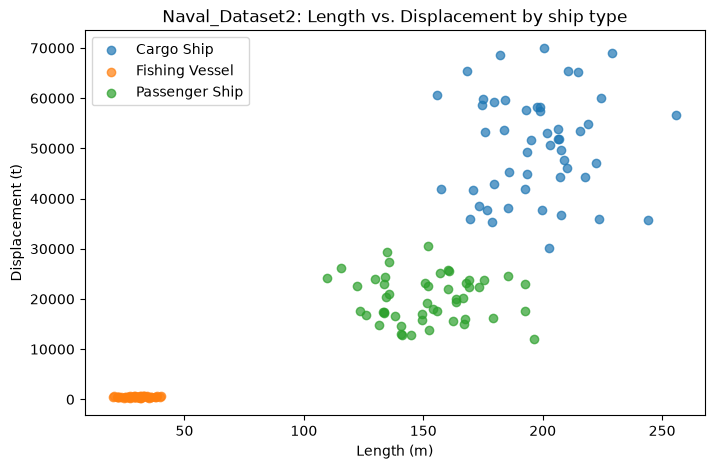

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for ship_type, group in ships2.groupby("Ship_Type"):
    ax.scatter(group["Length_m"], group["Displacement_t"], label=ship_type, alpha=0.7)
ax.set_xlabel("Length (m)")
ax.set_ylabel("Displacement (t)")
ax.set_title("Naval_Dataset2: Length vs. Displacement by ship type")
ax.legend()
plt.show()


**Comparing to the class's `Naval_Dataset.csv`**: the same EDA workflow
(`head`, `info`, `describe`, filter, `groupby`, `.corr()`, plot) worked
unchanged on `Naval_Dataset2.csv` -- confirming the "same column structure"
claim in the homework prompt is accurate. The specific correlation values and
group means differ from the original dataset (different underlying ships), but
the strong positive correlation between `Length_m` and `Displacement_t` shows
up here too, which makes physical sense: longer ships are heavier ships,
independent of which specific sample of the fleet we look at.


## Homework 4 — `%timeit`: a manual mean vs. NumPy's `.mean()`

I compare a hand-written pure-Python mean function against NumPy's built-in
`.mean()` on the same array, following the class's own `%timeit`/`%prun`
profiling style (Section: Debugging, Reset, and Timing/Profiling).


In [12]:
import numpy as np

rng = np.random.default_rng(0)
values = rng.normal(loc=100.0, scale=15.0, size=100_000)

def manual_mean(arr):
    total = 0.0
    for x in arr:
        total += x
    return total / len(arr)

print("manual_mean:", manual_mean(values))
print("np.mean:    ", values.mean())


manual_mean: 99.9863762384026
np.mean:     99.9863762384032


Time the pure-Python `manual_mean` loop:

In [13]:
%timeit manual_mean(values)


8.08 ms ± 411 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Time NumPy's built-in `mean` for comparison:

In [14]:
%timeit values.mean()


22.8 μs ± 99.8 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


**Which is faster, and why?** NumPy's `.mean()` was dramatically faster than
the manual pure-Python loop (the exact numbers are in the two `%timeit` cells
above -- both ran on the same 100,000-element array on this machine). This is
expected: the manual loop pays Python's per-iteration interpreter overhead
(bytecode dispatch, dynamic type checks) 100,000 times, while `values.mean()`
runs a single vectorized pass implemented in compiled C, operating on
contiguous memory with no per-element Python overhead. This is the same point
`NB03` makes about array mechanics: real numerical work should almost always
go through NumPy's vectorized operations rather than explicit Python loops,
both for speed and for more concise code.
